# Lasso Regression

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn import linear_model or we can import lasso directly
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(f"E:\AI and ML\Section Three\Supervised ML\insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X = df.drop(columns=["charges"])
y = df["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int) # Picked region as column on which we want to do our one hot encoding
# get_dummies returning dummy variables

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

# Train_Test_Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42) # 80-20 ratio

# Using Lasso Model

In [6]:
lasso_model = Lasso(alpha=0.5) # We pass alpha value in it & using Lasso model
lasso_model.fit(X_train, y_train)

# For MSE
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

In [7]:
print(mse)

33601197.56637193


MSE for 0.001 is: 33596924.38828374
MSE for 0.1 is: 33597770.05720262
MSE for 1 is: 33605507.57554603
MSE for 2 is: 33614211.30874086
MSE for 5 is: 33639750.85985903
MSE for 10 is: 33679511.30099594
MSE for 20 is: 33766604.71529101
MSE for 35 is: 33900832.422080435
MSE for 50 is: 34042719.501167394
MSE for 100 is: 34245283.94567648


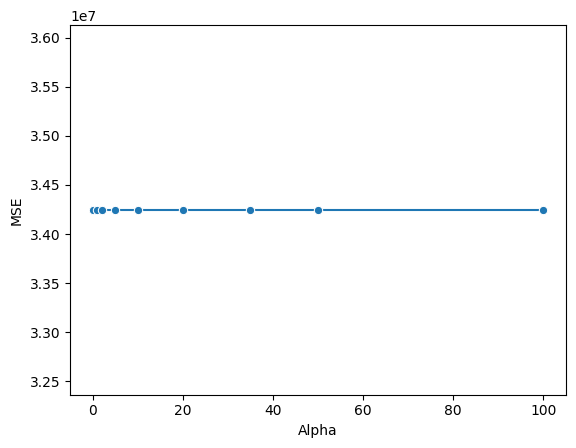

In [8]:
# Using seaborn to display in a graph
alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 35, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha = a) # We pass alpha value in it.
    lasso_model.fit(X_train, y_train)

    # For MSE
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for {a} is:" , mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mse, marker="o")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.show()


# LassoCV

In [9]:
a = [0.001, 0.1, 1, 2, 5, 10, 20, 35, 50, 100]

lasso_cv_model = LassoCV(alphas=a, cv=5, max_iter=50, random_state=42)

lasso_cv_model.fit(X_train, y_train) # it will identify best alpha value

print("Best alpha: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

Best alpha:  100.0


In [10]:
print(mse)

34245283.94567648


In [11]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.7794166585670872


# RidgeCV

In [ ]:
# Same syntax as LassoCV only with few changes in parameters

a = [0.001, 0.1, 1, 2, 5, 10, 20, 35, 50, 100]

ridge_cv_model = RidgeCV(alphas=a, cv=5)

ridge_cv_model.fit(X_train, y_train) # it will identify best alpha value

print("Best alpha: ", ridge_cv_model.alpha_)

y_pred = ridge_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

Best alpha:  1.0


In [13]:
print(mse)

33645037.09177903
